# Taller 4 — Sistema de búsqueda y recuperación de artículos científicos

**Minería de Datos (2016325) · Universidad Nacional de Colombia**

Corpus: artículos de *ACM Transactions on Graphics* almacenados en la base
SQLite construida en el Taller 1 (`tog_q1_2025.sqlite`). La aplicación
Streamlit del Taller 2 se amplía con un módulo de búsqueda que conserva todas
las funcionalidades anteriores.

## Resumen de las decisiones tomadas

| Decisión | Elección | Sección |
|---|---|---|
| Campos del documento | título (ponderado ×3) + resumen | §2 |
| Procesamiento | minúsculas, sin diacríticos, sin puntuación (guion interno conservado), *stopwords* inglesas + relleno académico, sin *stemming* | §3 |
| Representación léxica | frecuencias crudas, unigramas, vocabulario completo (BM25) | §4 |
| Representación vectorial | TF-IDF sublineal, unigramas + bigramas, `min_df=2`, `max_df=0.5` | §4 |
| Reducción dimensional | Truncated SVD (LSA), 2 943 → 40 dimensiones | §5 |
| Estrategia A | **BM25 Okapi** (léxica), `k1=1.5`, `b=0.75` | §6 |
| Estrategia B | **LSA**: TF-IDF + SVD + coseno (semántica, reducida) | §6 |
| Estrategia C | TF-IDF completo + coseno (referencia sin reducir) | §6 |
| Estrategia D | **Híbrido** BM25 + LSA por *Reciprocal Rank Fusion* | §6 |
| Evaluación | 6 consultas, juicios binarios manuales, P@5 · MRR · nDCG@5 · Recall@10 | §7 |

Todo el código del buscador vive en `ir.py`; este notebook, el script
`build_index.py` y la aplicación `app.py` importan **el mismo módulo**, de modo
que lo que se documenta aquí es literalmente lo que corre en la app.

## §1 · Configuración

In [1]:
import sys, time, platform, sqlite3
from pathlib import Path

import numpy as np
import pandas as pd
import scipy.sparse as sp
import sklearn
import matplotlib
import matplotlib.pyplot as plt

import ir
import evaluacion as ev

matplotlib.rcParams.update({
    "figure.figsize": (7.2, 3.4), "figure.dpi": 110, "font.size": 9,
    "axes.spines.top": False, "axes.spines.right": False, "axes.grid": True,
    "grid.color": "#e6e6e6", "grid.linewidth": .6, "savefig.bbox": "tight",
})
pd.set_option("display.width", 130)
pd.set_option("display.max_colwidth", 70)

DB = "tog_q1_2025.sqlite"
print("Python      :", sys.version.split()[0], "·", platform.platform())
print("numpy       :", np.__version__)
print("pandas      :", pd.__version__)
print("scipy       :", sp.__version__ if hasattr(sp, "__version__") else "n/a")
print("scikit-learn:", sklearn.__version__)

Python      : 3.12.3 · Linux-6.18.5-x86_64-with-glibc2.39
numpy       : 2.4.4
pandas      : 3.0.2
scipy       : n/a
scikit-learn: 1.8.0


## §2 · Construcción del corpus (enunciado §4.1)

### Campos utilizados

La base del Taller 1 tiene una tabla `papers` con 14 columnas. Para representar
el contenido de cada artículo solo hay dos campos de texto libre:

* `title` — título del artículo;
* `abstract` — resumen.

**No existe un campo de palabras clave.** El scraper del Taller 1 no capturó
los *CCS Concepts* ni los *Author Keywords* de ACM, así que la base no los
tiene. El enunciado pide usar las palabras clave *«cuando estén disponibles»* y
prohíbe reemplazar texto faltante por contenido inventado, de modo que el
corpus se construye únicamente con título y resumen. El campo `topic_label`
(categoría asignada por reglas en el Taller 1) **no** entra en el texto
indexado: es una etiqueta derivada de ese mismo texto, así que incluirla sería
realimentar la representación con información redundante; se usa solo para
mostrar la categoría en los resultados.

### Documento virtual y ponderación del título

Cada artículo se representa como

$$\texttt{doc} = \underbrace{\texttt{título} + \texttt{título} + \texttt{título}}_{\text{3 repeticiones}} + \texttt{resumen}$$

Repetir el título triplica la frecuencia de sus términos, que es la forma
estándar de ponderar campos cuando se usa un único índice: en BM25 el peso
entra por la frecuencia de término (con saturación) y en TF-IDF por el `tf`.
Se escogió ×3 porque el título mide del orden de 10 tokens frente a ~120 del
resumen: sin ponderar, un término que aparece solo en el título quedaría
prácticamente invisible.

In [2]:
corpus = ir.construir_corpus(DB)
print("artículos:", len(corpus))
corpus[["paper_id", "title", "publication_date", "topic_label"]].head(5)

artículos: 204


,paper_id,title,publication_date,topic_label
0,1,Speed-Aware Audio-Driven Speech Animation using Adaptive Windows,01 October 2024,Machine Learning
1,2,RNA: Relightable Neural Assets,01 October 2024,Estadística
2,3,DAMO: A Deep Solver for Arbitrary Marker Configuration in Optical ...,01 October 2024,Otro
3,4,TriHuman: A Real-time and Controllable Tri-plane Representation fo...,09 October 2024,Otro
4,5,PhysFiT: Physical-aware 3D Shape Understanding for Finishing Incom...,13 November 2024,Machine Learning


In [3]:
ir.diagnostico_corpus(corpus)

,indicador,valor
0,artículos en la base,204
1,artículos incluidos en el índice,204
2,sin título,0
3,sin resumen (abstract),0
4,sin palabras clave (campo inexistente en la BD),204
5,sin DOI,0
6,sin fecha de publicación,0
7,tokens por documento (mediana),119
8,tokens por documento (mínimo),34
9,tokens por documento (máximo),214


### Valores faltantes y criterios de inclusión

* **Criterio de inclusión.** Se indexa todo artículo con al menos un campo de
  texto no vacío (título o resumen). En esta base los 204 artículos cumplen la
  condición, así que no se excluyó ninguno.
* **Tratamiento de faltantes.** No hubo títulos ni resúmenes vacíos que
  imputar. Para el resto de campos: `year` tiene 7 nulos en la base, que el
  módulo `db.py` del Taller 2 reconstruye parseando `publication_date`; ese
  campo solo se muestra, no participa del ranking. Las palabras clave, al no
  existir la columna, se documentan como ausentes y no se sustituyen por nada.
* **Duplicados.** El `doi` es `UNIQUE` en el esquema y la inserción del
  scraper verifica el DOI antes de insertar, así que no hay artículos repetidos.

### Idiomas presentes

In [4]:
# Heurística de idioma: presencia de palabras función inglesas en el texto crudo.
# No se usa una librería de detección para no agregar dependencias a la app.
FUNC_EN = {"the", "and", "of", "with", "for", "that", "this", "from", "are", "we"}
FUNC_ES = {"el", "la", "los", "las", "de", "que", "con", "para", "una", "por"}

def cuenta_funcion(texto, vocab):
    palabras = set(str(texto).lower().split())
    return len(palabras & vocab)

marcas_en = corpus["abstract"].map(lambda t: cuenta_funcion(t, FUNC_EN))
marcas_es = corpus["abstract"].map(lambda t: cuenta_funcion(t, FUNC_ES))

print(f"resúmenes con ≥3 marcadores del inglés : {(marcas_en >= 3).sum()} de {len(corpus)}")
print(f"resúmenes con ≥3 marcadores del español: {(marcas_es >= 3).sum()} de {len(corpus)}")
print(f"resúmenes sin ningún marcador del inglés: {(marcas_en == 0).sum()}")

resúmenes con ≥3 marcadores del inglés : 201 de 204
resúmenes con ≥3 marcadores del español: 0 de 204
resúmenes sin ningún marcador del inglés: 0


El corpus es **monolingüe en inglés**, como corresponde a una revista de ACM.
Esto justifica dos decisiones: usar la lista de *stopwords* inglesa de
scikit-learn y no montar ningún tratamiento multilingüe. Las consultas de
evaluación se escriben también en inglés; una consulta en español solo
funcionaría por coincidencia de términos técnicos compartidos (*«render»*,
*«simulation»*), limitación que se discute en §9.

## §3 · Procesamiento del texto (enunciado §4.2)

| Operación | ¿Se aplica? | Justificación |
|---|---|---|
| Minúsculas | **Sí** | *«Rendering»* y *«rendering»* son el mismo término; en los títulos de ToG la capitalización es inconsistente (*Title Case* vs. minúsculas). |
| Normalización de caracteres (NFKD + descarte de diacríticos) | **Sí** | Los abstracts traen nombres propios acentuados (*Bézier*, *Möbius*, *Hašan*) y comillas tipográficas. Sin normalizar, *«bezier»* escrito por el usuario no encontraría *«Bézier»*. |
| Tokenización | Por espacios sobre el texto normalizado | Suficiente para texto científico ya limpio; evita la dependencia de un tokenizador entrenado. |
| Puntuación | **Se elimina**, salvo el guion interno | El guion es semántico en este dominio: *real-time*, *out-of-core*, *signed-distance*, *level-of-detail* son términos unitarios. |
| Números sueltos | **Se eliminan** | Años, números de ecuación y tamaños de malla no discriminan tema. Se conservan los alfanuméricos (*bm25*, *l2*, *3d*) porque sí lo hacen. |
| Tokens de <3 caracteres | **Se eliminan** | Iniciales de autores y símbolos matemáticos sueltos. |
| *Stopwords* | **Sí**: lista inglesa de scikit-learn + relleno académico | Además de las funcionales, se agregan ~50 términos que aparecen en casi todos los abstracts (*novel*, *method*, *propose*, *results*, *state of the art*). Un término presente en el 90 % del corpus no separa nada y sí ensucia el espacio latente. |
| *Stemming* | **No** | En gráficos por computador el recorte de sufijos fusiona objetos distintos: *rendering* (la disciplina) con *render*, *shading* con *shade*, *mapping* con *map*. Se prefiere pagar el costo de no unir variantes morfológicas y dejar que la reducción dimensional (§5) las relacione vía co-ocurrencia, que es precisamente lo que LSA hace bien. |
| Lematización | **No** | Requeriría un modelo (spaCy / NLTK con descarga de datos), lo que rompe el requisito de que la app corra sin recursos externos y en Streamlit Cloud. El beneficio esperado sobre *stemming* es marginal en texto técnico. |
| *n*-gramas | Unigramas para BM25; **unigramas + bigramas** para TF-IDF/LSA | Los bigramas capturan términos compuestos (*signed distance*, *material point*, *level set*, *radiance field*) que como unigramas separados son ambiguos. BM25 se queda en unigramas porque su modelo probabilístico ya pondera la rareza de cada término y los bigramas inflarían el vocabulario al doble sin ganancia clara. |

In [5]:
ejemplo = corpus.loc[corpus.paper_id == 13, "title"].iat[0] + " — " + \
          corpus.loc[corpus.paper_id == 13, "abstract"].iat[0][:220]
print("ORIGINAL:\n", ejemplo, "\n")
print("NORMALIZADO:\n", ir.normalizar(ejemplo)[:320], "\n")
print("TOKENS:\n", ir.tokenizar(ejemplo)[:28], "\n")
print("BIGRAMAS (muestra):\n", [g for g in ir.analizador_ngramas(ejemplo) if " " in g][:12])
print("\nstopwords totales:", len(ir.STOPWORDS),
      f"(scikit-learn: {len(ir.STOPWORDS) - len(ir.STOPWORDS_EXTRA)}, añadidas: {len(ir.STOPWORDS_EXTRA)})")

ORIGINAL:
 Sphere Carving: Bounding Volumes for Signed Distance Fields — We introduce Sphere Carving , a novel method for automatically computing bounding volumes that closely bound a procedurally defined implicit surface. Starting from an initial bounding volume located far from the object,  

NORMALIZADO:
 sphere carving bounding volumes for signed distance fields we introduce sphere carving a novel method for automatically computing bounding volumes that closely bound a procedurally defined implicit surface starting from an initial bounding volume located far from the object  

TOKENS:
 ['sphere', 'carving', 'bounding', 'volumes', 'signed', 'distance', 'fields', 'sphere', 'carving', 'automatically', 'computing', 'bounding', 'volumes', 'closely', 'bound', 'procedurally', 'defined', 'implicit', 'surface', 'starting', 'initial', 'bounding', 'volume', 'located', 'far', 'object'] 

BIGRAMAS (muestra):
 ['sphere carving', 'carving bounding', 'bounding volumes', 'volumes signed', 'signed d

count    204.0
mean     116.9
std       35.6
min       34.0
25%       94.5
50%      119.0
75%      139.2
max      214.0


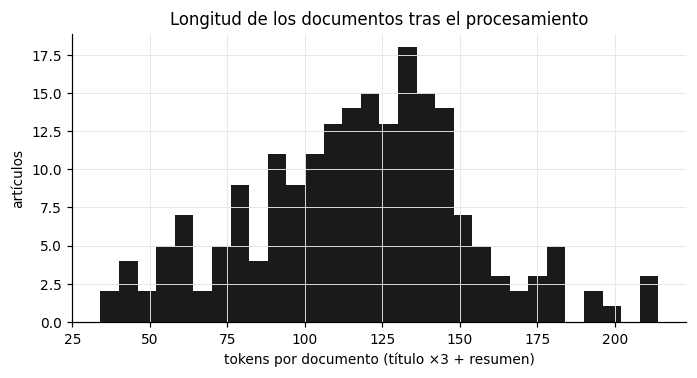

In [6]:
n_tok = corpus["doc_text"].map(lambda t: len(ir.tokenizar(t)))
print(n_tok.describe().round(1).to_string())
fig, ax = plt.subplots()
ax.hist(n_tok, bins=30, color="#1a1a1a")
ax.set_xlabel("tokens por documento (título ×3 + resumen)"); ax.set_ylabel("artículos")
ax.set_title("Longitud de los documentos tras el procesamiento")
plt.show()

La longitud varía por un factor cercano a 5 entre el artículo más corto y el
más largo. Esto es lo que hace necesaria la normalización por longitud de BM25
(el parámetro `b`): sin ella, los abstracts largos acumularían coincidencias
por el simple hecho de tener más palabras.

## §4 · Representación vectorial (enunciado §4.3)

Se construyen **dos** representaciones, una por estrategia.

**(a) Matriz de frecuencias para BM25.** `CountVectorizer` con el tokenizador
de §3, unigramas y **sin recorte de vocabulario** (`min_df=1`). BM25 necesita
poder emparejar términos raros, que son justamente los más informativos: si se
recortaran los términos que aparecen en un solo artículo, una consulta como
*«hexahedral»* perdería su mejor evidencia.

**(b) Matriz TF-IDF para las estrategias vectoriales.** `TfidfVectorizer` con
unigramas y bigramas, `sublinear_tf=True` (peso $1+\log tf$: la décima
aparición de un término aporta mucho menos que la segunda), `min_df=2` y
`max_df=0.5`. El recorte cumple dos funciones: controla el tamaño del
vocabulario —requisito computacional del enunciado— y, sobre todo, elimina el
ruido de términos que aparecen una sola vez, que en un SVD generan direcciones
espurias.

In [7]:
t0 = time.perf_counter()
idx = ir.construir_indice(DB)
t_build = time.perf_counter() - t0
info, par = idx["info"], idx["params"]

X, Z, W = idx["X"], idx["Z"], idx["bm25_W"]
resumen_rep = pd.DataFrame([
    {"representación": "Frecuencias (BM25)", "filas": W.shape[0], "columnas": W.shape[1],
     "tipo": "dispersa CSR", "no nulos": int(W.nnz),
     "densidad": round(W.nnz / (W.shape[0] * W.shape[1]), 5),
     "memoria KiB": round((W.data.nbytes + W.indices.nbytes + W.indptr.nbytes) / 1024, 1)},
    {"representación": "TF-IDF (uni+bigramas)", "filas": X.shape[0], "columnas": X.shape[1],
     "tipo": "dispersa CSR", "no nulos": int(X.nnz),
     "densidad": round(X.nnz / (X.shape[0] * X.shape[1]), 5),
     "memoria KiB": round((X.data.nbytes + X.indices.nbytes + X.indptr.nbytes) / 1024, 1)},
    {"representación": "Latente (SVD)", "filas": Z.shape[0], "columnas": Z.shape[1],
     "tipo": "densa float32", "no nulos": int(Z.size),
     "densidad": 1.0, "memoria KiB": round(Z.nbytes / 1024, 1)},
])
print(resumen_rep.to_string(index=False))
print()
print(f"TF-IDF como matriz densa float64 ocuparía "
      f"{X.shape[0] * X.shape[1] * 8 / 1024:,.1f} KiB "
      f"({X.shape[0] * X.shape[1] * 8 / (X.nnz * 12):.1f}× la versión dispersa).")
print(f"Tiempo total de construcción del índice: {t_build:.2f} s")

       representación  filas  columnas          tipo  no nulos  densidad  memoria KiB
   Frecuencias (BM25)    204      5080  dispersa CSR     16003   0.01544        125.8
TF-IDF (uni+bigramas)    204      2943  dispersa CSR     14971   0.02494        176.2
        Latente (SVD)    204        40 densa float32      8160   1.00000         31.9

TF-IDF como matriz densa float64 ocuparía 4,690.4 KiB (26.7× la versión dispersa).
Tiempo total de construcción del índice: 0.23 s


In [8]:
# Términos con mayor peso idf global (los más discriminativos) y los más frecuentes
idf = idx["tfidf"].idf_
vocab = np.array(idx["tfidf"].get_feature_names_out())
df_t = idx["bm25_df"]
vocab_bm = np.array(sorted(idx["bm25_vocab"], key=idx["bm25_vocab"].get))
top_frec = pd.DataFrame({
    "término": vocab_bm[np.argsort(-df_t)[:12]],
    "artículos en que aparece": np.sort(df_t)[::-1][:12],
})
print("Términos más frecuentes del corpus (tras quitar stopwords):")
print(top_frec.to_string(index=False))

Términos más frecuentes del corpus (tras quitar stopwords):
     término  artículos en que aparece
    existing                        59
   framework                        56
       model                        56
      models                        50
   rendering                        47
  simulation                        46
         key                        45
applications                        45
     surface                        44
     complex                        44
      design                        42
   including                        41


### Ventajas y limitaciones de la representación elegida

**Ventajas.** La matriz dispersa cabe en unos cientos de kibibytes; el
vocabulario es interpretable (cada dimensión es un término, y se puede auditar
por qué un artículo subió en el ranking); no requiere modelos preentrenados ni
GPU ni conexión a internet, así que la app despliega en Streamlit Cloud sin
problemas.

**Limitaciones.** TF-IDF y BM25 no saben nada de sinonimia: *«garment»* y
*«cloth»* son dimensiones ortogonales. Tampoco capturan orden ni sintaxis más
allá de los bigramas, ni polisemia: *«body»* en este corpus significa casi
siempre *cuerpo rígido*, no *cuerpo humano*, y el modelo no puede distinguirlo
(esto se materializa en la consulta C5 de §7). El corpus de 204 artículos es
pequeño, lo que hace que el idf sea inestable para términos poco frecuentes.

## §5 · Reducción de dimensionalidad (enunciado §2.4 y §4.5)

**Método: Truncated SVD (LSA).** Se escoge sobre PCA porque opera
directamente sobre la matriz dispersa: PCA exige centrar los datos, y centrar
destruye la dispersión (los ceros dejan de ser ceros) convirtiendo la matriz de
204 × 2 943 en densa. NMF daría componentes no negativos e interpretables pero
es iterativo y bastante más lento; ICA busca independencia estadística, que no
es el criterio útil aquí; un autoencoder es imposible de justificar con 204
ejemplos de entrenamiento. Truncated SVD es además la recomendación explícita
del enunciado para matrices dispersas de texto.

**Qué información conserva.** El SVD factoriza $X \approx U_k \Sigma_k V_k^\top$
y conserva las $k$ direcciones de máxima varianza de la matriz término-documento.
Esas direcciones son combinaciones lineales de términos que co-ocurren; cada
componente actúa como un «tema latente». Dos artículos que hablan de lo mismo
con palabras distintas quedan cerca en el espacio latente aunque su producto
punto en TF-IDF sea casi nulo. Lo que se pierde es la identidad de los términos
individuales: la coincidencia exacta de un término raro se diluye entre los
componentes, y por eso el espacio latente **no** reemplaza a BM25 sino que lo
complementa.

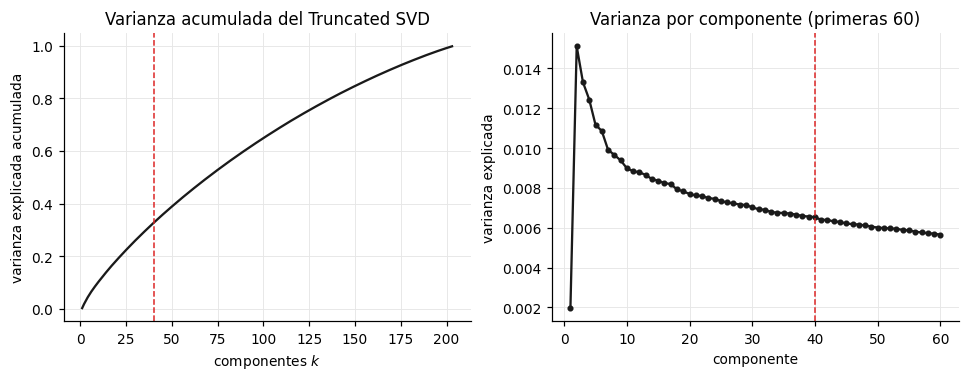

k =  20  →  varianza acumulada 18.6%
k =  40  →  varianza acumulada 32.6%
k =  60  →  varianza acumulada 44.7%
k = 100  →  varianza acumulada 64.9%
k = 150  →  varianza acumulada 84.7%
k = 203  →  varianza acumulada 99.8%


In [9]:
from sklearn.decomposition import TruncatedSVD

k_max = min(X.shape) - 1
svd_full = TruncatedSVD(n_components=k_max, random_state=ir.SVD_SEED).fit(X)
var_acum = np.cumsum(svd_full.explained_variance_ratio_)

fig, (a1, a2) = plt.subplots(1, 2, figsize=(10.5, 3.4))
a1.plot(range(1, k_max + 1), var_acum, color="#1a1a1a")
a1.axvline(ir.SVD_COMPONENTS, color="#dc2626", ls="--", lw=1)
a1.set_xlabel("componentes $k$"); a1.set_ylabel("varianza explicada acumulada")
a1.set_title("Varianza acumulada del Truncated SVD")
a2.plot(range(1, 61), svd_full.explained_variance_ratio_[:60], color="#1a1a1a", marker=".")
a2.axvline(ir.SVD_COMPONENTS, color="#dc2626", ls="--", lw=1)
a2.set_xlabel("componente"); a2.set_ylabel("varianza explicada")
a2.set_title("Varianza por componente (primeras 60)")
plt.show()

for k in (20, 40, 60, 100, 150, k_max):
    print(f"k = {k:3}  →  varianza acumulada {var_acum[k-1]:.1%}")

La curva de varianza **no tiene un codo pronunciado**: el corpus es
temáticamente homogéneo (toda la revista es gráficos por computador), así que
la señal está repartida entre muchas direcciones de magnitud parecida. Con
204 documentos el rango de la matriz está acotado por 204, de modo que llegar
al 90 % de varianza exigiría ~180 componentes, es decir, casi no reducir nada.

Por eso el criterio de varianza sirve como referencia pero **no** decide. El
criterio operativo es la calidad de recuperación: se reconstruye el índice para
varios valores de $k$ y se evalúan las 6 consultas de §7.

In [10]:
barrido = ev.barrido_componentes(DB, valores=(20, 25, 30, 35, 40, 50, 60, 80, 100, 150))
print(barrido.to_string(index=False))

 componentes  varianza_explicada    P@5    MRR  nDCG@5  Recall@10  ms_promedio
          20              0.1854 0.4000 0.6722  0.4432     0.4489         0.65
          25              0.2224 0.4667 0.7708  0.5216     0.6059         0.68
          30              0.2585 0.5333 0.8333  0.5863     0.5407         0.65
          35              0.2925 0.5667 0.7500  0.5809     0.5434         0.66
          40              0.3254 0.5000 0.7685  0.5347     0.6681         0.70
          50              0.3874 0.5000 0.7500  0.5357     0.5737         0.67
          60              0.4456 0.5000 0.6389  0.5138     0.6070         0.84
          80              0.5522 0.4333 0.5972  0.4523     0.6347         0.80
         100              0.6477 0.5000 0.6111  0.5000     0.6069         0.76
         150              0.8464 0.5000 0.6210  0.4961     0.6416         0.98


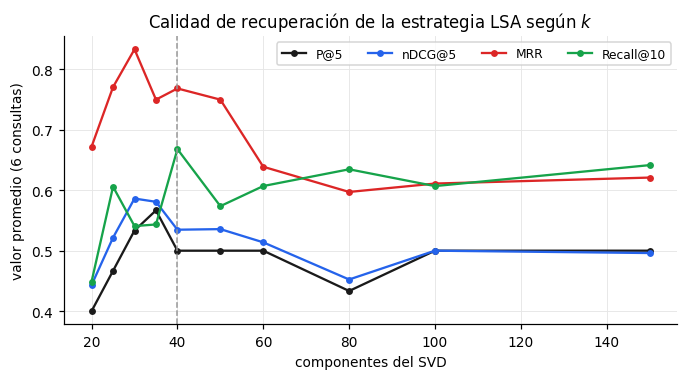

In [11]:
fig, ax = plt.subplots()
for col, c in [("P@5", "#1a1a1a"), ("nDCG@5", "#2563eb"),
               ("MRR", "#dc2626"), ("Recall@10", "#16a34a")]:
    ax.plot(barrido["componentes"], barrido[col], marker="o", ms=3.5, label=col, color=c)
ax.axvline(ir.SVD_COMPONENTS, color="#999", ls="--", lw=1)
ax.set_xlabel("componentes del SVD"); ax.set_ylabel("valor promedio (6 consultas)")
ax.set_title("Calidad de recuperación de la estrategia LSA según $k$")
ax.legend(ncols=4, fontsize=8)
plt.show()

### Elección: $k = 40$

Entre $k \approx 25$ y $k \approx 55$ las cuatro métricas forman una **meseta**;
por debajo de 25 el espacio es demasiado grosero y por encima de 60 la calidad
cae y luego se estabiliza en valores peores, porque al retener más componentes
el espacio latente se parece cada vez más al TF-IDF original y pierde su
capacidad de suavizar el vocabulario. Se toma $k = 40$ como punto medio de esa
meseta: tiene el mejor Recall@10 del barrido y está entre los mejores en MRR y
nDCG@5.

Es importante ser honesto sobre el alcance de este criterio: con 6 consultas
las métricas son ruidosas y la diferencia entre $k=30$ y $k=40$ no es
estadísticamente significativa. Se escoge el centro de la meseta precisamente
para no sobreajustar a un óptimo puntual del conjunto de evaluación.

* **Dimensión original:** 2 943 (vocabulario TF-IDF de unigramas + bigramas).
* **Dimensión final:** 40.
* **Reducción:** 98,6 % de las dimensiones; la varianza retenida es del 32,5 %.

### Proyección de la consulta al mismo espacio

Este es el punto donde es fácil equivocarse: la consulta **no** puede
vectorizarse aparte. El procedimiento es:

1. `tfidf.transform([consulta])` — usa el **mismo vocabulario y los mismos
   pesos idf** aprendidos del corpus (nunca `fit`, que recalcularía el idf con
   un solo documento);
2. `svd.transform(q_tfidf)` — multiplica por la **misma** matriz de
   componentes $V_k$ que se usó para los artículos;
3. normalización $\ell_2$, para que el producto punto contra `Z` (que ya está
   normalizada) sea exactamente el coseno.

Los términos de la consulta que no están en el vocabulario simplemente no
aportan; si **ninguno** está, el vector queda nulo y el buscador informa que no
hay resultados en lugar de devolver ruido.

In [12]:
q = "differentiable rendering of implicit surfaces"
q_tfidf = ir.vector_consulta_tfidf(idx, q)
q_lat = ir.proyectar_consulta_lsa(idx, q)
print(f"consulta: «{q}»")
print(f"  vector TF-IDF : dimensión {q_tfidf.shape[1]:,}, {q_tfidf.nnz} componentes no nulos")
print(f"  vector latente: dimensión {q_lat.shape[0]}, norma {np.linalg.norm(q_lat):.4f}")
print(f"  términos reconocidos: {[t for t in ir.analizador_ngramas(q) if t in idx['tfidf'].vocabulary_][:10]}")

# Verificación: el coseno latente aproxima el coseno completo
s_full = ir.puntajes_tfidf(idx, q)
s_lat = ir.puntajes_lsa(idx, q)
from scipy.stats import spearmanr, kendalltau
rho = spearmanr(s_full, s_lat).statistic
tau = kendalltau(np.argsort(-s_full)[:20], np.argsort(-s_lat)[:20]).statistic
print(f"\ncorrelación de Spearman entre puntajes TF-IDF completo y latente: {rho:.3f}")
print(f"artículos comunes en el top-10 de ambos: "
      f"{len(set(np.argsort(-s_full)[:10]) & set(np.argsort(-s_lat)[:10]))}/10")

consulta: «differentiable rendering of implicit surfaces»
  vector TF-IDF : dimensión 2,943, 6 componentes no nulos
  vector latente: dimensión 40, norma 1.0000
  términos reconocidos: ['differentiable', 'rendering', 'implicit', 'surfaces', 'differentiable rendering', 'implicit surfaces']

correlación de Spearman entre puntajes TF-IDF completo y latente: 0.723
artículos comunes en el top-10 de ambos: 9/10


In [13]:
# Efecto de la reducción en memoria y tiempo de respuesta
def kib(m):
    if sp.issparse(m):
        return (m.data.nbytes + m.indices.nbytes + m.indptr.nbytes) / 1024
    return m.nbytes / 1024

consultas_bench = [c["texto"] for c in ev.CONSULTAS]
tiempos = {}
for m in ["bm25", "tfidf", "lsa", "hibrido"]:
    t = []
    for _ in range(30):
        for c in consultas_bench:
            t0 = time.perf_counter(); ir.buscar(idx, c, m, 10); t.append((time.perf_counter() - t0) * 1000)
    tiempos[m] = (float(np.median(t)), float(np.percentile(t, 95)))

comp = pd.DataFrame([
    {"estrategia": "TF-IDF completo", "estructura": f"dispersa {X.shape[0]}×{X.shape[1]:,}",
     "memoria KiB": round(kib(X), 1),
     "ms (mediana)": round(tiempos["tfidf"][0], 2), "ms (p95)": round(tiempos["tfidf"][1], 2)},
    {"estrategia": "LSA reducida", "estructura": f"densa {Z.shape[0]}×{Z.shape[1]}",
     "memoria KiB": round(kib(Z), 1),
     "ms (mediana)": round(tiempos["lsa"][0], 2), "ms (p95)": round(tiempos["lsa"][1], 2)},
    {"estrategia": "BM25", "estructura": f"dispersa {W.shape[0]}×{W.shape[1]:,}",
     "memoria KiB": round(kib(W), 1),
     "ms (mediana)": round(tiempos["bm25"][0], 2), "ms (p95)": round(tiempos["bm25"][1], 2)},
    {"estrategia": "Híbrido (RRF)", "estructura": "BM25 + LSA",
     "memoria KiB": round(kib(W) + kib(Z), 1),
     "ms (mediana)": round(tiempos["hibrido"][0], 2), "ms (p95)": round(tiempos["hibrido"][1], 2)},
])
print(comp.to_string(index=False))

     estrategia         estructura  memoria KiB  ms (mediana)  ms (p95)
TF-IDF completo dispersa 204×2,943        176.2          4.10      4.47
   LSA reducida       densa 204×40         31.9          4.34      5.01
           BM25 dispersa 204×5,080        125.8          3.82      4.61
  Híbrido (RRF)         BM25 + LSA        157.7          4.44      5.13


**Efecto de la reducción.** La matriz latente ocupa unas 32 KiB frente a las
~176 KiB de la TF-IDF dispersa (y frente a los ~4,6 MiB que ocuparía densa), y
el puntaje se calcula con un producto matriz-vector de 204 × 40 en vez de
recorrer una matriz dispersa. En un corpus de este tamaño **ambas responden en
pocos milisegundos**, así que la reducción no se justifica por velocidad: se
justifica porque cambia *qué* recupera el sistema, mejorando la calidad del
ranking (§7). La ganancia de memoria y tiempo sería la relevante en un corpus
de cientos de miles de documentos.

**Efecto sobre el ranking.** La correlación de Spearman entre el puntaje
TF-IDF completo y el latente es alta pero lejos de 1 (≈0,72 en la consulta de
ejemplo) y 9 de los 10 primeros resultados coinciden: la reducción **no**
reescribe el ranking, lo reordena. Las diferencias son pocas pero caen en la
cabeza de la lista, que es justamente lo que ve el usuario, y en §7 se ve que
esos pocos cambios mueven las métricas en la dirección correcta.

## §6 · Tipo de recuperación y mecanismo de ranking (enunciado §4.4 y §4.6)

### Estrategia A — BM25 Okapi · recuperación **léxica**

$$\text{score}(q,d) = \sum_{t \in q} \text{qtf}_t \cdot \underbrace{\ln\!\left(1 + \frac{N - df_t + 0.5}{df_t + 0.5}\right)}_{\text{idf}} \cdot \frac{tf_{t,d}\,(k_1+1)}{tf_{t,d} + k_1\!\left(1 - b + b\,\frac{|d|}{\overline{|d|}}\right)}$$

Un artículo es relevante si **comparte términos** con la consulta, y el aporte
de cada término crece con su rareza (idf), se satura con su frecuencia (el
segundo *«mesh»* aporta mucho menos que el primero, controlado por
$k_1 = 1{,}5$) y se corrige por la longitud del documento ($b = 0{,}75$, para
que un abstract largo no gane solo por ser largo). El puntaje **no está
acotado**: depende del número de términos de la consulta y de su rareza.

Implementación: la matriz de pesos $W$ se precalcula completa en
`build_index.py`, así que puntuar una consulta es sumar unas pocas columnas de
una matriz dispersa.

### Estrategia B — LSA · recuperación **semántica** sobre representación reducida

$$\text{score}(q,d) = \cos\!\big(\hat{z}_q,\, \hat{z}_d\big) = \hat{z}_q^\top \hat{z}_d, \qquad \hat{z} = \frac{V_k^\top x}{\|V_k^\top x\|}$$

Un artículo es relevante si **ocupa la misma región temática** que la consulta
en el espacio de 40 dimensiones, aunque no comparta ninguna palabra. El puntaje
está en $[-1, 1]$ y es directamente interpretable como similitud.

### Estrategia C — TF-IDF completo · referencia

Idéntica a B pero sin reducir: sirve exclusivamente para aislar el efecto de la
reducción dimensional (mismo texto, misma métrica, misma consulta; solo cambia
el espacio).

### Estrategia D — Híbrido por *Reciprocal Rank Fusion*

$$\text{RRF}(d) = \sum_{m \in \{\text{BM25},\,\text{LSA}\}} \frac{1}{k + \text{rank}_m(d)}, \qquad k = 60$$

RRF resuelve el problema de que los puntajes de A y B viven en escalas
distintas: **solo usa las posiciones**, así que no requiere normalizar nada ni
elegir un peso arbitrario entre métodos. Un artículo bien posicionado en las dos
listas gana; uno que solo aparece en una queda por detrás pero sigue presente.

### Orden, empates y comparabilidad

* Los artículos se ordenan por puntaje descendente.
* **Empates:** se rompen por número de citas (descendente) y luego por
  `paper_id` (ascendente). El desempate por citas es un criterio secundario —el
  ranking principal siempre proviene de la representación numérica del texto—,
  y el `paper_id` final garantiza que el orden sea determinista y reproducible.
* Los artículos con puntaje $\le 0$ se descartan: no hay evidencia textual de
  relevancia y mostrarlos sería relleno.
* **Los puntajes de estrategias distintas no son comparables.** Un 12,4 de BM25
  y un 0,75 de coseno latente no se pueden contrastar; la app lo advierte
  explícitamente en el modo de comparación. Lo comparable es el orden.

In [14]:
demo = ir.buscar(idx, "differentiable rendering of implicit surfaces", "lsa", 5)
demo[["posicion", "paper_id", "title", "puntaje", "topic_label", "citations"]]

,posicion,paper_id,title,puntaje,topic_label,citations
0,1,140,Neurally Integrated Finite Elements for Differentiable Elasticity ...,0.657131,Machine Learning,2
1,2,194,Quadric-Based Silhouette Sampling for Differentiable Rendering,0.632865,Estadística,0
2,3,193,Moment Bounds are Differentiable: Efficiently Approximating Measur...,0.606792,Otro,0
3,4,61,Practical Gaussian Process Implicit Surfaces with Sparse Convolutions,0.562761,Estadística,0
4,5,77,Painless Differentiable Rotation Dynamics,0.562676,Otro,0


## §7 · Evaluación de los resultados (enunciado §5)

### Consultas y juicios de relevancia

Se definieron **6 consultas** que cubren las cinco categorías exigidas. Los
juicios de relevancia son binarios y se asignaron manualmente leyendo título y
resumen de cada candidato. El conjunto juzgado se obtuvo por *pooling*: la
unión de los 10 primeros resultados de las cuatro estrategias. Cada consulta
declara por escrito su criterio de relevancia, en `evaluacion.py`, para que el
juicio sea auditable y no una caja negra.

Consecuencia metodológica: como el pool no es el corpus completo, **Recall@k es
optimista** (podría haber artículos relevantes que ninguna estrategia recuperó).
Precision@5, MRR y nDCG@5 sí son directamente comparables entre estrategias,
porque todas se evalúan contra los mismos juicios.

In [15]:
tabla_q = pd.DataFrame([
    {"id": c["id"], "tipo": c["tipo"], "consulta": c["texto"],
     "n relevantes": len(c["relevantes"])}
    for c in ev.CONSULTAS
])
print(tabla_q.to_string(index=False))

id                                                 tipo                                                                   consulta  n relevantes
C1                        Términos literales del corpus                                                 hexahedral mesh extraction             7
C2                    Términos relacionados / sinónimos              teaching virtual characters to move using learned controllers             6
C3                                     Consulta general                                                   physics-based simulation            11
C4                                  Consulta específica                                bounding volumes for signed distance fields             5
C5 Consulta donde se esperan resultados poco relevantes                   simulating how clothes wrinkle and fold on a moving body             6
C6      Consulta en lenguaje natural (estilo enunciado) applications of generative artificial intelligence for creating 3D content

In [16]:
metricas, detalle = ev.evaluar(idx)
print("Promedio sobre las 6 consultas:\n")
print(ev.resumen(metricas).to_string())

Promedio sobre las 6 consultas:

               P@5     MRR  nDCG@5  Recall@10      ms
estrategia                                           
bm25        0.4333  0.6111  0.4435     0.6138  0.3767
lsa         0.5000  0.7685  0.5347     0.6681  0.8500
tfidf       0.4667  0.6250  0.4742     0.5930  0.6567
hibrido     0.5000  0.6667  0.5074     0.7348  1.2700


Precision@5 por consulta y estrategia:

estrategia  bm25  lsa  tfidf  hibrido
consulta                             
C1           0.6  0.6    0.6      0.6
C2           0.4  0.6    0.6      0.4
C3           1.0  0.8    1.0      1.0
C4           0.4  0.6    0.4      0.6
C5           0.0  0.0    0.0      0.0
C6           0.2  0.4    0.2      0.4


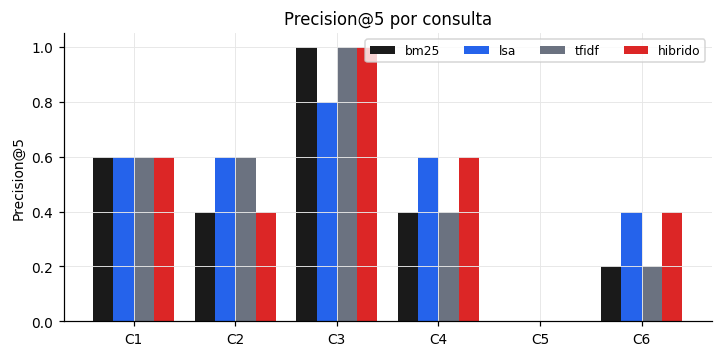

In [17]:
pivote = metricas.pivot(index="consulta", columns="estrategia", values="P@5")[ev.METODOS_EVAL]
print("Precision@5 por consulta y estrategia:\n")
print(pivote.to_string())

fig, ax = plt.subplots(figsize=(7.6, 3.4))
x = np.arange(len(pivote)); w = 0.2
for i, (m, c) in enumerate(zip(ev.METODOS_EVAL,
                               ["#1a1a1a", "#2563eb", "#6b7280", "#dc2626"])):
    ax.bar(x + (i - 1.5) * w, pivote[m], w, label=m, color=c)
ax.set_xticks(x); ax.set_xticklabels(pivote.index)
ax.set_ylabel("Precision@5"); ax.set_ylim(0, 1.05)
ax.set_title("Precision@5 por consulta")
ax.legend(ncols=4, fontsize=8)
plt.show()

In [18]:
# Rankings lado a lado para cada consulta
for c in ev.CONSULTAS:
    print("=" * 108)
    print(f"{c['id']} · {c['tipo']}\n  «{c['texto']}»")
    for m in ["bm25", "lsa"]:
        sub = detalle[(detalle.consulta == c["id"]) & (detalle.estrategia == m)].head(5)
        print(f"  ── {m}")
        for _, r in sub.iterrows():
            print(f"     {r.posicion}. {'✔' if r.relevante else '✘'} "
                  f"[{r.paper_id:3}] {r.titulo[:78]:78} {r.puntaje:.4f}")

C1 · Términos literales del corpus
  «hexahedral mesh extraction»
  ── bm25
     1. ✔ [ 18] HexHex: Highspeed Extraction of Hexahedral Meshes                              21.3868
     2. ✔ [ 19] TetWeave: Isosurface Extraction using On-The-Fly Delaunay Tetrahedral Grids fo 10.6563
     3. ✘ [132] Direct Rendering of Intrinsic Triangulations                                   7.9536
     4. ✘ [ 12] Dynamic Mesh Processing on the GPU                                             4.2463
     5. ✔ [175] IMLS-Splatting: Efficient Mesh Reconstruction from Multi-view Images via Point 4.1082
  ── lsa
     1. ✔ [ 18] HexHex: Highspeed Extraction of Hexahedral Meshes                              0.7922
     2. ✔ [ 19] TetWeave: Isosurface Extraction using On-The-Fly Delaunay Tetrahedral Grids fo 0.7872
     3. ✘ [ 88] Exact Predicates, Exact Constructions and Combinatorics for Mesh CSG.          0.6294
     4. ✘ [132] Direct Rendering of Intrinsic Triangulations                                   0.

### Análisis consulta por consulta

**C1 · «hexahedral mesh extraction» (términos literales). P@5 = 0,6 en las
cuatro estrategias.** Todas colocan primero *HexHex: Highspeed Extraction of
Hexahedral Meshes* —la respuesta exacta, con los tres términos en el título— y
segundo *TetWeave*. BM25 le da a HexHex un puntaje desproporcionado (21,4 frente
a 10,7 del segundo) porque *«hexahedral»* aparece en muy pocos artículos y su
idf es enorme. A partir de la posición 3 los dos métodos se equivocan de forma
distinta pero equivalente en cantidad: BM25 sube *Dynamic Mesh Processing on the
GPU*, que repite *«mesh»* muchas veces pero procesa mallas ya existentes en vez
de extraerlas; LSA sube *Exact Predicates … for Mesh CSG*, del mismo vecindario
de geometría computacional pero cuyo aporte es la intersección booleana.
Conclusión: cuando la consulta usa el vocabulario exacto del corpus, la
estrategia léxica ya es suficiente y la reducción no aporta.

**C2 · «teaching virtual characters to move using learned controllers»
(sinónimos). BM25 = 0,4 · LSA = 0,6; MRR 0,25 contra 1,00.** Ningún artículo
objetivo usa *«teaching»* ni *«learned controllers»*: hablan de *«skills»*,
*«policy»*, *«control»*. BM25 se ancla en los dos términos literales más
frecuentes y menos informativos de la consulta —*«virtual»* y *«controller»*— y
llena las tres primeras posiciones con *VR-Doh* (modelado en realidad virtual),
*A Highly-Efficient Hybrid Simulation System for Flight Controller Design*
(controladores de drones) y un *Virtual Oculoplastic Surgery Simulator*:
coincidencia léxica perfecta, relevancia nula. LSA pone *ViSA* primero y
*PhysicsFC* tercero, que son exactamente control aprendido de personajes
físicos, sin compartir ningún término con la consulta. **Este es el caso que
justifica la reducción dimensional:** el espacio latente asocia
*«characters»*, *«skills»* y *«control»* porque co-ocurren en el corpus, no
porque coincidan como cadenas.

**C3 · «physics-based simulation» (general). BM25, TF-IDF e híbrido = 1,0 ·
LSA = 0,8.** Aquí gana la estrategia léxica, y el motivo es instructivo: la
consulta es literalmente una frase del corpus (*«physics-based»* está en varios
títulos), así que la coincidencia exacta es la señal correcta y no hay nada que
desambiguar. El único error de LSA es *Creating Fluid-Interactive Virtual
Agents*, que quedó juzgado como no relevante porque su aporte es un entorno
interactivo, no un método de simulación; es el precio del suavizado latente:
al mezclar dimensiones acerca artículos del mismo barrio temático aunque su
contribución sea de otro tipo. También muestra un límite de la métrica: con 11
artículos relevantes en un corpus homogéneo, P@5 se satura y casi no
discrimina.

**C4 · «bounding volumes for signed distance fields» (específica).
BM25 = 0,4 · LSA = 0,6.** Las cuatro estrategias aciertan *Sphere Carving:
Bounding Volumes for Signed Distance Fields* en la posición 1 y *Synchronized
Tracing of Primitive-based Implicit Volumes* en la 2: una consulta larga con
varios términos raros que co-ocurren en un solo artículo es el caso fácil. La
diferencia está en el relleno: LSA recupera además *A Neural Particle Level Set
Method*, que es representación implícita de superficies sin usar las palabras
*«signed distance»*, mientras BM25 llena con artículos que solo comparten
*«volumetric»* o *«fields»*.

**C5 · «simulating how clothes wrinkle and fold on a moving body» (fallo
esperado). P@5 = 0 en las cuatro estrategias.** Ninguno de los seis artículos
de tela del corpus (*High-performance CPU Cloth Simulation*, *Real-Time Knit
Deformation*, *Progressive Dynamics++*, *StiffGIPC*, *Dress-1-to-3*,
*Predicting Fabric Appearance*) entra en el top-5 de ningún método. Dos causas
concretas:

1. **Desajuste morfológico.** El corpus dice *cloth*, *knit*, *garment*,
   *outfit*; la consulta dice *clothes*. Son tokens distintos y, al no aplicar
   *stemming* (§3), no se unen. Es el costo explícito de esa decisión.
2. **Polisemia.** *«body»* en este corpus designa cuerpos **rígidos**: arrastra
   *Putting Rigid Bodies to Rest* (posición 4 en BM25 y en LSA) y *A Versatile
   Quaternion-Based Constrained Rigid Body Dynamics*. El término más pesado de
   la consulta apunta al vecindario equivocado.

LSA no rescata la consulta, y eso es lo interesante: su vector queda dominado
por las mismas dimensiones latentes de dinámica de cuerpos rígidos que activan
*«simulating»*, *«body»* y *«moving»*. **El espacio latente hereda el
vocabulario del corpus**: solo puede relacionar lo que co-ocurre en él, y
*«clothes»* no aparece nunca. El resultado más engañoso es
*CFC: Simulating Character-Fluid Coupling*, primero en las cuatro estrategias:
comparte *«simulating»*, *«character»* y la idea de un cuerpo deformable en
movimiento, pero simula fluidos.

**C6 · «applications of generative artificial intelligence for creating 3D
content» (lenguaje natural). BM25 = 0,2 · LSA = 0,4.** La consulta más difícil
de las seis, porque el corpus tiene muchos artículos de IA generativa **2D**
(edición de imágenes, diseño gráfico, personalización de difusión) con
vocabulario casi idéntico al de los 3D. BM25 se deja llevar por coincidencias
sueltas: *«content»* le trae *B4M: Breaking Low-Rank Adapter for Making
Content-Style Customization* y *«creating»* le trae *Creating Fluid-Interactive
Virtual Agents*; su único acierto aparece en la posición 4. LSA acierta dos de
los tres primeros (*BANG: Dividing 3D Assets via Generative Exploded Dynamics*
y *CAST: 3D Scene Reconstruction*), aunque también cae en el barrio 2D con
*TokenVerse* e *IntrinsicEdit*. Con la representación disponible, la señal que
separa «generativo 3D» de «generativo 2D» es demasiado débil: haría falta el
campo de palabras clave que la base no tiene, o embeddings entrenados con
más contexto.

### Comparación global

In [19]:
res = ev.resumen(metricas)
mejor = res["nDCG@5"].idxmax()
print(res.to_string())
print(f"\nMejor nDCG@5 promedio: {mejor}")
print(f"Mejor Recall@10      : {res['Recall@10'].idxmax()}")
print(f"Mejor MRR            : {res['MRR'].idxmax()}")

               P@5     MRR  nDCG@5  Recall@10      ms
estrategia                                           
bm25        0.4333  0.6111  0.4435     0.6138  0.3767
lsa         0.5000  0.7685  0.5347     0.6681  0.8500
tfidf       0.4667  0.6250  0.4742     0.5930  0.6567
hibrido     0.5000  0.6667  0.5074     0.7348  1.2700

Mejor nDCG@5 promedio: lsa
Mejor Recall@10      : hibrido
Mejor MRR            : lsa


**Qué estrategia produjo mejores resultados.** La **LSA sobre la
representación reducida** gana en promedio en las tres métricas de precisión y
ordenamiento (P@5 0,500 · nDCG@5 0,535 · MRR 0,769) frente a BM25 (0,433 ·
0,444 · 0,611). El desglose por consulta muestra que la ventaja no es uniforme
y explica de dónde sale: LSA gana claramente en C2 (sinónimos), C4
(específica) y C6 (lenguaje natural), empata en C1 (términos literales) y C5
(fallo total de ambas), y **pierde** en C3 (general), donde la consulta es una
frase literal del corpus y el suavizado latente solo puede introducir ruido.
Es decir: la reducción semántica paga cuando el usuario no conoce el
vocabulario exacto de la revista, y cuesta un poco cuando sí lo conoce.

El **híbrido RRF** iguala la precisión de LSA (P@5 0,500) y consigue el mejor
Recall@10 (0,735 contra 0,668), porque recupera la unión de los aciertos de
ambas listas. Es la opción más razonable por defecto si el usuario piensa
revisar más allá de los cinco primeros resultados.

Comparar B contra C aísla el efecto de la reducción: **la reducción a 40
dimensiones no solo no degrada el ranking, lo mejora** frente al TF-IDF
completo con la misma métrica y el mismo texto. El SVD está actuando como
filtro de ruido, descartando las direcciones que solo capturan idiosincrasias
de redacción.

**Advertencia honesta sobre estos números.** Seis consultas y juicios de un
solo evaluador no permiten afirmar significancia estadística; las diferencias
entre estrategias son del orden del ruido esperable. Lo que sí es sólido es la
explicación cualitativa de *por qué* cada método falla donde falla (C2 y C5),
que es reproducible e inspeccionable en el detalle de los rankings.

## §8 · Integración en la aplicación (enunciado §4.7)

Arquitectura, para que no haya ninguna diferencia entre lo documentado y lo
ejecutado:

```
ir.py            módulo único con procesamiento, BM25, TF-IDF, LSA y RRF
                 ↑ lo importan build_index.py, este notebook y app.py
build_index.py   se ejecuta UNA vez  →  index/ir_index.joblib
app.py           carga el índice con @st.cache_resource y solo consulta
```

* **Nada se recalcula en caliente.** El índice se construye fuera de la app y se
  guarda con `joblib`. En `app.py` la carga está envuelta en
  `@st.cache_resource`, cuya clave incluye la fecha de modificación del
  archivo: se carga una sola vez por proceso, y si se reconstruye el índice la
  caché se invalida sola. Cada búsqueda es una suma de columnas dispersas
  (BM25) o un producto de 204 × 40 (LSA).
* **Las cuatro estrategias del notebook son las cuatro de la app**, con los
  mismos parámetros, porque salen del mismo módulo y del mismo archivo de
  índice. La app ofrece además el modo *«Comparar BM25 vs LSA»*, que muestra los
  dos rankings lado a lado para una misma consulta y marca los artículos
  comunes.
* **Resultados mostrados:** posición, título, autores (deduplicados con
  `db.autores_legibles`), fecha, categoría, DOI enlazado, puntaje y un fragmento
  del resumen centrado en el primer término de la consulta que aparezca.
* **El usuario elige** cuántos resultados ver (5, 10 o 20) y qué estrategia usar.
* **Se conservan todas las funcionalidades del Taller 2:** filtros del sidebar,
  indicadores, visualizaciones Plotly, tabla de artículos, consulta SQL de solo
  lectura y actualización por scraping. El buscador se agregó como sección 3 y
  las demás se renumeraron.
* **Coherencia índice–base:** si la base tiene más artículos que el índice
  (por ejemplo después de un scraping), la app muestra un aviso pidiendo
  reconstruirlo. No lo reconstruye sola, para no bloquear la interfaz.

## §9 · Consideraciones computacionales (enunciado §6)

In [20]:
import os
ruta = ir.guardar_indice(idx)
print(f"índice: {ruta}  →  {ruta.stat().st_size / 1024 / 1024:.2f} MB")

pico = (kib(X) + kib(W) + Z.nbytes / 1024) / 1024
print(f"estructuras del buscador en memoria: {pico:.2f} MiB")
print(f"corpus completo (texto crudo)       : "
      f"{corpus['doc_text'].str.len().sum() / 1024 / 1024:.2f} MiB")
print(f"base SQLite                         : "
      f"{os.path.getsize(DB) / 1024 / 1024:.2f} MiB")

índice: /home/claude/taller4/index/ir_index.joblib  →  1.32 MB
estructuras del buscador en memoria: 0.33 MiB
corpus completo (texto crudo)       : 0.28 MiB
base SQLite                         : 6.00 MiB


El sistema completo ocupa **menos de 2 MiB** de memoria para las estructuras del
buscador, muy por debajo del límite de 16 GB del enunciado. Cómo se logra:

* las matrices de texto se mantienen **dispersas** (CSR) en todo momento; en
  ningún punto se llama a `.todense()` sobre la matriz completa (solo sobre el
  vector de una consulta, de 2 943 posiciones);
* el vocabulario TF-IDF se limita con `min_df=2` (fuera los términos de un solo
  artículo) y `max_df=0.5` (fuera los ubicuos), pasando de ~5 100 a 2 943
  términos, con la justificación metodológica de §4 —no solo por ahorro;
* Truncated SVD opera directamente sobre la matriz dispersa, sin densificarla;
* las representaciones se **precalculan** en `build_index.py` y se guardan
  comprimidas;
* la app las carga una vez con `@st.cache_resource`;
* **no** se entrena ni descarga ningún modelo neuronal, y **no** se depende de
  ninguna API de pago: todo el cómputo es `scikit-learn` + `scipy` sobre CPU.

**Limitaciones conocidas.** (i) El sistema es monolingüe: una consulta en
español solo funciona por los términos técnicos que comparte con el inglés.
(ii) No hay palabras clave porque la base no las tiene; incorporarlas exigiría
volver a hacer scraping de los *CCS Concepts*, lo que probablemente mejoraría
la recuperación temática. (iii) Sin *stemming*, la variación morfológica
(*clothes*/*cloth*) rompe la coincidencia léxica, como se vio en C5. (iv) Los
juicios de relevancia son de un solo evaluador y sobre 6 consultas.

## §10 · Conclusiones

1. Se implementaron cuatro estrategias de recuperación —una léxica (BM25), una
   semántica sobre representación reducida (LSA con 40 dimensiones), una
   vectorial completa como control (TF-IDF) y una híbrida (RRF)— y todas están
   disponibles en la aplicación.
2. La reducción dimensional **no es un anexo del documento**: la matriz latente
   de 204 × 40 es la que produce el ranking por defecto del buscador, y la
   consulta del usuario se proyecta al mismo espacio con el mismo `TfidfVectorizer`
   y el mismo modelo SVD.
3. Reducir de 2 943 a 40 dimensiones (98,6 % menos) **mejoró** la calidad del
   ranking frente al TF-IDF completo, en particular en la consulta expresada
   con sinónimos, y redujo la memoria de la representación de ~176 KiB a ~32 KiB.
4. Las dos familias de métodos fallan de maneras distintas y complementarias:
   BM25 se rompe cuando la consulta no comparte vocabulario con los artículos
   (C2); LSA se rompe cuando el vecindario latente correcto no existe en el
   corpus (C5) o cuando la señal útil está en un término literal raro. El
   híbrido por RRF es la opción más robusta en cobertura.